In [1]:
print("hello wec")

hello wec


first thing is importing the data 
i have chosen the movielens data 
let see how the data looks

In [2]:
import pandas as pd
df = pd.read_csv(
    'ml-100k/u.data', 
    sep='\t', 
    header=None, 
    names=['user_id', 'item_id', 'rating', 'timestamp']
)

In [3]:
df
nousers = df["user_id"].nunique()
nomovies  = df["item_id"].nunique()

checking the data

In [4]:
df.head()
# df.tail()
df.isnull().sum() # so there are no null values 
df.shape

(100000, 4)

In [5]:
user_item_matrix = df.pivot(index='user_id', columns='item_id', values='rating').fillna(0)
# print(user_item_matrix.shape) 
# print(user_item_matrix.head())
user_item_matrix.head()

item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


what the above tabel means is that on one user id or a user how many movies it has watched and rated and rating 0 means it hasent seen or rated on it 



In [6]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(df,test_size=0.2, random_state=42)
train_data
# test_data


,user_id,item_id,rating,timestamp
75220,807,1411,1,893082619
48955,474,659,5,887925187
44966,463,268,4,877384940
13568,139,286,4,879537844
92727,621,751,4,883799651
...,...,...,...,...
6265,216,231,2,880245109
54886,343,276,5,876403078
76820,437,475,3,880140288
860,284,322,3,885329671


In [7]:
train_user_item_matrix = train_data.pivot(index='user_id', columns='item_id', values='rating').fillna(0)

In [8]:
train_user_item_matrix
# test_data


item_id,1,2,3,4,5,6,7,8,9,10,...,1668,1670,1671,1672,1673,1676,1678,1679,1680,1681
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,3.0,4.0,0.0,3.0,0.0,4.0,0.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
940,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
941,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
from sklearn.metrics.pairwise import cosine_similarity
# now we compute the cosine simlarity matrix  be each users 
cosine_sim_matrix = cosine_similarity(train_user_item_matrix)

In [10]:
cosine_sim_matrix.shape
type(cosine_sim_matrix) 
train_user_item_matrix.index
cosine_sim_matrix
cosine_sim_df = pd.DataFrame(
    cosine_sim_matrix, 
    index=train_user_item_matrix.index, 
    columns=train_user_item_matrix.index
)
cosine_sim_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.136196,0.030424,0.026203,0.284613,0.331412,0.319056,0.274139,0.083486,0.281396,...,0.277459,0.084849,0.205849,0.144161,0.133679,0.092367,0.216948,0.084181,0.104599,0.329288
2,0.136196,1.000000,0.114644,0.168220,0.093128,0.162165,0.095848,0.091360,0.149476,0.125701,...,0.149359,0.268977,0.320095,0.323347,0.241012,0.152655,0.230951,0.117484,0.166632,0.096719
3,0.030424,0.114644,1.000000,0.346894,0.000000,0.085071,0.032829,0.053875,0.060177,0.052552,...,0.021713,0.017707,0.154299,0.049358,0.107604,0.019022,0.101207,0.021959,0.127179,0.013805
4,0.026203,0.168220,0.346894,1.000000,0.011848,0.051287,0.075209,0.142100,0.060465,0.035202,...,0.034908,0.044480,0.087428,0.118082,0.100612,0.000000,0.151086,0.110324,0.112342,0.032367
5,0.284613,0.093128,0.000000,0.011848,1.000000,0.168527,0.298438,0.185290,0.039737,0.166013,...,0.276012,0.103529,0.085547,0.072429,0.104445,0.049198,0.204472,0.148028,0.099978,0.247527


In [11]:
#now lets do for the pearson so we have two methods to find the relation bw the users to predict the rating
pearson_sim_df = train_user_item_matrix.T.corr(method='pearson', min_periods=1).fillna(0)

In [12]:
pearson_sim_df
# pearson_sim_df.shape
# so now both are done 

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.088475,-0.021909,-0.010971,0.216604,0.254853,0.204153,0.233354,0.055869,0.204544,...,0.203412,0.042700,0.131358,0.105430,0.066620,0.049274,0.154905,0.054101,0.042240,0.263153
2,0.088475,1.000000,0.092622,0.153687,0.053788,0.120272,0.029460,0.065653,0.136981,0.084014,...,0.110464,0.253015,0.292347,0.308313,0.214169,0.133484,0.202912,0.103340,0.139773,0.056219
3,-0.021909,0.092622,1.000000,0.336313,-0.041339,0.041193,-0.036811,0.028702,0.046925,0.009439,...,-0.021407,-0.002592,0.120872,0.029363,0.077722,-0.001897,0.070135,0.007010,0.100743,-0.028335
4,-0.010971,0.153687,0.336313,1.000000,-0.017156,0.019076,0.031394,0.126095,0.050942,0.004094,...,0.004959,0.030401,0.061997,0.104887,0.079556,-0.015220,0.130993,0.100604,0.093502,0.003239
5,0.216604,0.053788,-0.041339,-0.017156,1.000000,0.096456,0.212987,0.147800,0.016232,0.098196,...,0.219438,0.071709,0.019909,0.038569,0.051172,0.013783,0.155633,0.127049,0.051829,0.190599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,0.049274,0.133484,-0.001897,-0.015220,0.013783,0.027241,0.004581,0.072237,0.047986,-0.025599,...,0.002503,0.298261,0.153723,0.181776,0.322324,1.000000,0.039990,0.144039,-0.004748,0.097808
940,0.154905,0.202912,0.070135,0.130993,0.155633,0.221977,0.224720,0.128495,0.074801,0.240237,...,0.217000,0.035971,0.089714,0.104589,0.010704,0.039990,1.000000,0.066519,0.188940,0.167567
941,0.054101,0.103340,0.007010,0.100604,0.127049,0.101787,-0.018663,0.065738,0.134245,0.041674,...,0.010310,0.190911,0.180634,0.225381,0.178285,0.144039,0.066519,1.000000,0.079141,0.092390


In [13]:
# now making a funtion for to predict 
test_data
# 1. what if  the users is not  there on the trainng set so we cant compute its neighbours
#2.

,user_id,item_id,rating,timestamp
75721,877,381,4,882677345
80184,815,602,3,878694269
19864,94,431,4,891721716
76699,416,875,2,876696938
92991,500,182,2,883873556
...,...,...,...,...
32595,72,591,5,880035708
29313,523,393,5,883702411
37862,606,287,4,880921656
53421,650,612,4,891369656


In [14]:
def predicition(user, item,df,k):
    if (item in df.columns) and (user in df.index):
        checkrows = df[(df[item] > 0) & (df.index != user)]
        has_greater_than_zero = len(checkrows) > 0
        if has_greater_than_zero==True :
            resultpearson = pearson_sim_df.loc[pearson_sim_df.index.isin(checkrows.index), [user]].sort_values(by=user, ascending=False)
            resultcosine = cosine_sim_df.loc[cosine_sim_df.index.isin(checkrows.index), [user]].sort_values(by=user, ascending=False)
            topp = resultpearson.head(k)
            topc = resultcosine.head(k)
            avgpearson = df.reindex(topp.index)[item].mean()
            avgcosine = df.reindex(topc.index)[item].mean()
            return [avgpearson,avgcosine]
        else :
            print("this movie ist rated by any ppl so there will not be any")
            return None
    else :
        print("check ur users or item ")
        return None

def error(pearsoncosine,user,item,test_data ):
    personr = pearsoncosine[0]
    cosiner = pearsoncosine[1]
    actual = test_data.loc[(test_data['user_id'] == user) & (test_data['item_id'] == item), 'rating'].iloc[0]
    return [(personr - actual) ** 2, (cosiner - actual) ** 2]

In [15]:
# train_user_item_matrix.shape
# train_user_item_matrix
# test_data

In [16]:
# user = 4
# checkrows = train_user_item_matrix[(train_user_item_matrix[7] > 0) & (train_user_item_matrix.index != user)]
# resultpearson = pearson_sim_df.loc[pearson_sim_df.index.isin(checkrows.index), [user]].sort_values(by=user, ascending=False)
# resultcosine = cosine_sim_df.loc[cosine_sim_df.index.isin(checkrows.index), [user]].sort_values(by=user, ascending=False)

In [17]:
# resultpearson


In [18]:
# resultcosine

In [19]:
import numpy as np
a =[2,3,5,10 , 20 , 30 ,40 ]
for val in a :
    k = val
    sqerr_pearson = []
    sqerr_cosine = []
    for user, item in zip(test_data['user_id'], test_data['item_id']):
        pearsoncosine = predicition(user, item, train_user_item_matrix, k)
        if pearsoncosine is None:
            continue
        sp, sc = error(pearsoncosine, user, item, test_data)
        sqerr_pearson.append(sp)
        sqerr_cosine.append(sc)
    rmse_pearson = np.sqrt(np.mean(sqerr_pearson))
    rmse_cosine = np.sqrt(np.mean(sqerr_cosine))
    print(f"for k = {val} the errors are given below  ")
    print(f"pearson RMSE = {rmse_pearson}")
    print(f"cosine RMSE = {rmse_cosine}")
    print(f"test rows used = {len(sqerr_pearson)} out of {len(test_data)}")

check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
for k = 2 the errors are given below  
pearson RMSE = 1.1755389965864032
cosine RMSE = 1.1683549686057024
test rows used = 19969 out of 20000
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or item 
check ur users or 

now lets build the matrix model 

In [20]:
import pandas as pd 
import numpy as np
train_data


,user_id,item_id,rating,timestamp
75220,807,1411,1,893082619
48955,474,659,5,887925187
44966,463,268,4,877384940
13568,139,286,4,879537844
92727,621,751,4,883799651
...,...,...,...,...
6265,216,231,2,880245109
54886,343,276,5,876403078
76820,437,475,3,880140288
860,284,322,3,885329671


now making the matrix factorization model 

In [21]:
df

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [22]:
train_data
df.shape
df

nomovies
nousers
train_data

,user_id,item_id,rating,timestamp
75220,807,1411,1,893082619
48955,474,659,5,887925187
44966,463,268,4,877384940
13568,139,286,4,879537844
92727,621,751,4,883799651
...,...,...,...,...
6265,216,231,2,880245109
54886,343,276,5,876403078
76820,437,475,3,880140288
860,284,322,3,885329671


In [23]:
import numpy as np 

np.random.seed(42)
k = 10 


unique_users = train_data['user_id'].unique()
unique_items = train_data['item_id'].unique()

user_to_idx = {raw_id: i for i, raw_id in enumerate(unique_users)}
item_to_idx = {raw_id: i for i, raw_id in enumerate(unique_items)}
train_array = np.array([
    [user_to_idx[row.user_id], item_to_idx[row.item_id], row.rating]
    for row in train_data.itertuples()
])
P = np.random.randn(nousers, k) / np.sqrt(k)   
Q = np.random.randn(nomovies, k) / np.sqrt(k)   

           
# R_pred = P @ Q.T        
print(P.shape, Q.shape)
train_array

(943, 10) (1682, 10)


array([[  0,   0,   1],
       [  1,   1,   5],
       [  2,   2,   4],
       ...,
       [517, 231,   3],
       [268, 222,   3],
       [147,  46,   3]], shape=(80000, 3))

In [24]:
alpha = 0.01
lamb = 0.01
n_epochs = 20

for epoch in range(1, n_epochs + 1):
    print(f"epoch {epoch} starting")
    np.random.shuffle(train_array)            

    total_sq_err = 0

    for row in train_array:
        u = int(row[0])
        i = int(row[1])
        r = row[2]

        p_old = P[u].copy()
        q_old = Q[i].copy()

        pred = p_old @ q_old
        e = r - pred

        P[u] = p_old + 2*alpha*(e*q_old - lamb*p_old)
        Q[i] = q_old + 2*alpha*(e*p_old - lamb*q_old)

        total_sq_err += e**2

    rmse = np.sqrt(total_sq_err / len(train_array))
    print(f"epoch {epoch} ended, train RMSE = {rmse:.4f}")

epoch 1 starting
epoch 1 ended, train RMSE = 2.7004
epoch 2 starting
epoch 2 ended, train RMSE = 1.0835
epoch 3 starting
epoch 3 ended, train RMSE = 0.9682
epoch 4 starting
epoch 4 ended, train RMSE = 0.9267
epoch 5 starting
epoch 5 ended, train RMSE = 0.8998
epoch 6 starting
epoch 6 ended, train RMSE = 0.8794
epoch 7 starting
epoch 7 ended, train RMSE = 0.8631
epoch 8 starting
epoch 8 ended, train RMSE = 0.8486
epoch 9 starting
epoch 9 ended, train RMSE = 0.8355
epoch 10 starting
epoch 10 ended, train RMSE = 0.8260
epoch 11 starting
epoch 11 ended, train RMSE = 0.8164
epoch 12 starting
epoch 12 ended, train RMSE = 0.8082
epoch 13 starting
epoch 13 ended, train RMSE = 0.8015
epoch 14 starting
epoch 14 ended, train RMSE = 0.7949
epoch 15 starting
epoch 15 ended, train RMSE = 0.7894
epoch 16 starting
epoch 16 ended, train RMSE = 0.7851
epoch 17 starting
epoch 17 ended, train RMSE = 0.7804
epoch 18 starting
epoch 18 ended, train RMSE = 0.7768
epoch 19 starting
epoch 19 ended, train RMSE =

In [25]:
test_rows = []
skipped = 0

for row in test_data.itertuples():
    if row.user_id in user_to_idx and row.item_id in item_to_idx:
        test_rows.append([user_to_idx[row.user_id],
                          item_to_idx[row.item_id],
                          row.rating])
    else:
        skipped += 1          

test_array = np.array(test_rows)
print("kept:", len(test_array), "skipped:", skipped)
print(test_array[:5])         

kept: 19969 skipped: 31
[[ 360  347    4]
 [ 144 1015    3]
 [ 150  328    4]
 [ 205  445    2]
 [ 117  201    2]]


In [26]:
def evaluate(arr, P, Q, fallback):
    sq_err = 0

    for row in arr:
        u = int(row[0])
        i = int(row[1])
        r = row[2]

        if u == -1 or i == -1:   # this fall back will not work as i have removed all the rows not in the train set there 31 of them     
            pred = fallback           
        else:
            pred = P[u] @ Q[i]

        sq_err += (r - pred) ** 2

    rmse = np.sqrt(sq_err / len(arr))
    print(f"testing done, rmse = {rmse:.4f}")
    return rmse


global_mean = train_array[:, 2].mean()
test_rmse = evaluate(test_array, P, Q, global_mean)

testing done, rmse = 0.9997


# part 2 - weighted user based cf, comparison and conclusion

till now the user based cf just took the plain mean of the ratings of the top k neighbours. in the worked example of the task the neighbours are weighted by their similarity

$$\hat r_{ui} = \frac{\sum_{v \in N} s_{uv} \, r_{vi}}{\sum_{v \in N} s_{uv}}$$

so a neighbour with similarity 0.9 counts more than one with 0.3. also in the example charlie with similarity -0.8 is not a neighbour, so only the neighbours with similarity > 0 are used here. if there is no neighbour with positive similarity we fall back to the global mean rating of the train set. the same test rows as before are used (31 rows with unseen user or item are left out, same as in the matrix factorization part) so the comparison stays fair

In [27]:
def predict_weighted(user, item, ks, sim_df, df, fallback):
    if (item in df.columns) and (user in df.index):
        raters = df.index[(df[item] > 0) & (df.index != user)]
        sims = sim_df.loc[raters, user].sort_values(ascending=False).head(max(ks))
        sims = sims[sims > 0]
        preds = []
        for k in ks:
            top = sims.head(k)
            if len(top) == 0:
                preds.append(fallback)
            else:
                preds.append((top * df.loc[top.index, item]).sum() / top.sum())
        return preds
    else:
        return None

In [28]:
global_mean = train_data['rating'].mean()
ks = [2, 3, 5, 10, 20, 30, 40]

actual = []
pearson_preds = []
cosine_preds = []

for row in test_data.itertuples():
    pp = predict_weighted(row.user_id, row.item_id, ks, pearson_sim_df, train_user_item_matrix, global_mean)
    pc = predict_weighted(row.user_id, row.item_id, ks, cosine_sim_df, train_user_item_matrix, global_mean)
    if pp is None:
        continue
    actual.append(row.rating)
    pearson_preds.append(pp)
    cosine_preds.append(pc)

actual = np.array(actual)
pearson_preds = np.array(pearson_preds)
cosine_preds = np.array(cosine_preds)

weighted_pearson_rmse = np.sqrt(np.mean((pearson_preds - actual[:, None]) ** 2, axis=0))
weighted_cosine_rmse = np.sqrt(np.mean((cosine_preds - actual[:, None]) ** 2, axis=0))

print(f"test rows used = {len(actual)} out of {len(test_data)}")
for k, a, b in zip(ks, weighted_pearson_rmse, weighted_cosine_rmse):
    print(f"for k = {k} weighted pearson RMSE = {a:.4f} and weighted cosine RMSE = {b:.4f}")

test rows used = 19969 out of 20000
for k = 2 weighted pearson RMSE = 1.1763 and weighted cosine RMSE = 1.1689
for k = 3 weighted pearson RMSE = 1.1130 and weighted cosine RMSE = 1.1112
for k = 5 weighted pearson RMSE = 1.0606 and weighted cosine RMSE = 1.0608
for k = 10 weighted pearson RMSE = 1.0249 and weighted cosine RMSE = 1.0249
for k = 20 weighted pearson RMSE = 1.0099 and weighted cosine RMSE = 1.0105
for k = 30 weighted pearson RMSE = 1.0081 and weighted cosine RMSE = 1.0077
for k = 40 weighted pearson RMSE = 1.0078 and weighted cosine RMSE = 1.0080


the plain mean numbers below are copied from the output of the earlier loop (the cell with `predicition`), so we can put the plain and the weighted version side by side

In [29]:
plain_pearson_rmse = np.array([1.1755, 1.1118, 1.0587, 1.0229, 1.0086, 1.0078, 1.0079])
plain_cosine_rmse = np.array([1.1684, 1.1107, 1.0601, 1.0243, 1.0104, 1.0082, 1.0090])

knn_table = pd.DataFrame({
    'k': ks,
    'plain pearson': plain_pearson_rmse,
    'weighted pearson': weighted_pearson_rmse.round(4),
    'plain cosine': plain_cosine_rmse,
    'weighted cosine': weighted_cosine_rmse.round(4)
})
knn_table

,k,plain pearson,weighted pearson,plain cosine,weighted cosine
0,2,1.1755,1.1763,1.1684,1.1689
1,3,1.1118,1.1130,1.1107,1.1112
2,5,1.0587,1.0606,1.0601,1.0608
3,10,1.0229,1.0249,1.0243,1.0249
4,20,1.0086,1.0099,1.0104,1.0105
5,30,1.0078,1.0081,1.0082,1.0077
6,40,1.0079,1.0078,1.0090,1.0080


## matrix factorization again, this time with the test error tracked every epoch

the model above was trained without looking at the test set so we cannot see the learning curve. here the same model (same seed, same alpha, same lambda, same 20 epochs) is trained again and this time the train and test rmse are saved after every epoch. the final test rmse should come out the same as before

In [30]:
import time

train_array2 = np.column_stack([
    train_data['user_id'].map(user_to_idx).to_numpy(),
    train_data['item_id'].map(item_to_idx).to_numpy(),
    train_data['rating'].to_numpy()
])

def rmse_on(arr, P, Q):
    u = arr[:, 0].astype(int)
    i = arr[:, 1].astype(int)
    r = arr[:, 2]
    preds = np.sum(P[u] * Q[i], axis=1)
    return np.sqrt(np.mean((r - preds) ** 2))

np.random.seed(42)
k = 10
P2 = np.random.randn(nousers, k) / np.sqrt(k)
Q2 = np.random.randn(nomovies, k) / np.sqrt(k)

alpha = 0.01
lamb = 0.01
n_epochs = 20
train_curve = []
test_curve = []

start = time.time()
for epoch in range(1, n_epochs + 1):
    np.random.shuffle(train_array2)
    total_sq_err = 0

    for row in train_array2:
        u = int(row[0])
        i = int(row[1])
        r = row[2]

        p_old = P2[u].copy()
        q_old = Q2[i].copy()

        e = r - p_old @ q_old
        P2[u] = p_old + 2*alpha*(e*q_old - lamb*p_old)
        Q2[i] = q_old + 2*alpha*(e*p_old - lamb*q_old)
        total_sq_err += e**2

    train_curve.append(np.sqrt(total_sq_err / len(train_array2)))
    test_curve.append(rmse_on(test_array, P2, Q2))
    print(f"epoch {epoch} train RMSE = {train_curve[-1]:.4f} test RMSE = {test_curve[-1]:.4f}")
mf_train_time = time.time() - start
print(f"training time = {mf_train_time:.1f} seconds")

epoch 1 train RMSE = 2.7004 test RMSE = 1.2607


epoch 2 train RMSE = 1.0835 test RMSE = 1.0435


epoch 3 train RMSE = 0.9682 test RMSE = 1.0063


epoch 4 train RMSE = 0.9267 test RMSE = 0.9917


epoch 5 train RMSE = 0.8998 test RMSE = 0.9818


...

epoch 16 train RMSE = 0.7851 test RMSE = 0.9900


epoch 17 train RMSE = 0.7804 test RMSE = 0.9936


epoch 18 train RMSE = 0.7768 test RMSE = 0.9931


epoch 19 train RMSE = 0.7734 test RMSE = 0.9967


epoch 20 train RMSE = 0.7695 test RMSE = 0.9997
training time = 11.6 seconds


In [31]:
mf_preds = np.sum(P2[test_array[:, 0].astype(int)] * Q2[test_array[:, 1].astype(int)], axis=1)
mf_rmse = np.sqrt(np.mean((test_array[:, 2] - mf_preds) ** 2))
print(len(test_array), len(actual), np.all(test_array[:, 2] == actual))
print(f"matrix factorization test RMSE = {mf_rmse:.4f}")

19969 19969 True
matrix factorization test RMSE = 0.9997


the three checks printed above tell us that the test rows of both methods are the same rows in the same order and that the matrix factorization rmse is the same as the earlier run. so now both models are really judged on the same 19969 ratings

In [32]:
best_p = np.argmin(weighted_pearson_rmse)
best_c = np.argmin(weighted_cosine_rmse)

results = pd.DataFrame({
    'method': [
        f'user based cf, pearson, plain mean (k={ks[np.argmin(plain_pearson_rmse)]})',
        f'user based cf, cosine, plain mean (k={ks[np.argmin(plain_cosine_rmse)]})',
        f'user based cf, pearson, weighted (k={ks[best_p]})',
        f'user based cf, cosine, weighted (k={ks[best_c]})',
        'matrix factorization (k=10 factors, 20 epochs)',
        'matrix factorization (stopped at best epoch, see note)',
        'baseline, always predict the global mean'
    ],
    'test RMSE': [
        plain_pearson_rmse.min(),
        plain_cosine_rmse.min(),
        weighted_pearson_rmse[best_p],
        weighted_cosine_rmse[best_c],
        mf_rmse,
        min(test_curve),
        np.sqrt(np.mean((actual - global_mean) ** 2))
    ]
}).round(4)
results

,method,test RMSE
0,"user based cf, pearson, plain mean (k=30)",1.0078
1,"user based cf, cosine, plain mean (k=30)",1.0082
2,"user based cf, pearson, weighted (k=40)",1.0078
3,"user based cf, cosine, weighted (k=30)",1.0077
4,"matrix factorization (k=10 factors, 20 epochs)",0.9997
5,"matrix factorization (stopped at best epoch, s...",0.9763
6,"baseline, always predict the global mean",1.1228


note on the 6th row: the test rmse of matrix factorization is lowest at epoch 7 and then goes up again while the train rmse keeps going down. so the model starts to overfit. picking the epoch by looking at the test set is a bit optimistic (the proper way is a separate validation set), so the main number to quote is the 20 epoch one and the best epoch one only shows how much room is there

## speed of prediction

kNN has no training but every single prediction has to search the neighbours. matrix factorization needs training once but a prediction is just one dot product. both are timed here on the same 2000 test ratings with a normal python loop

In [33]:
sample = test_data.head(2000)
start = time.time()
for row in sample.itertuples():
    predict_weighted(row.user_id, row.item_id, [30], cosine_sim_df, train_user_item_matrix, global_mean)
knn_time = time.time() - start

sample_array = test_array[:2000]
start = time.time()
for row in sample_array:
    u = int(row[0])
    i = int(row[1])
    pred = P2[u] @ Q2[i]
mf_time = time.time() - start

print(f"kNN = {knn_time / 2000 * 1000:.3f} ms per prediction")
print(f"matrix factorization = {mf_time / 2000 * 1000:.4f} ms per prediction")
print(f"matrix factorization training time (one time) = {mf_train_time:.1f} seconds")

kNN = 0.597 ms per prediction
matrix factorization = 0.0013 ms per prediction
matrix factorization training time (one time) = 11.6 seconds


## plots

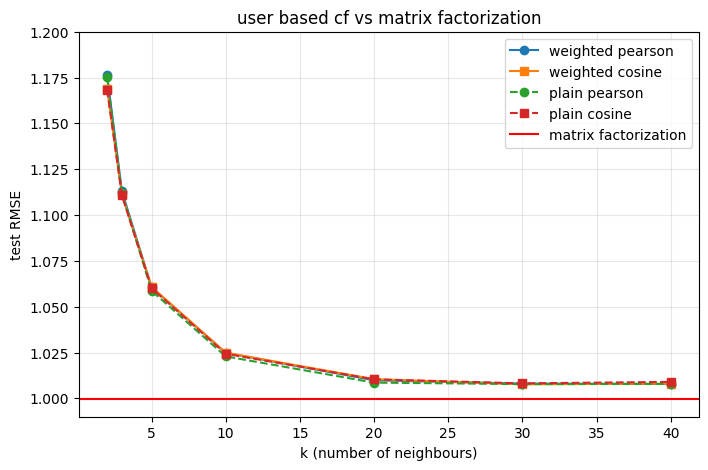

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(ks, weighted_pearson_rmse, marker='o', label='weighted pearson')
plt.plot(ks, weighted_cosine_rmse, marker='s', label='weighted cosine')
plt.plot(ks, plain_pearson_rmse, marker='o', linestyle='--', label='plain pearson')
plt.plot(ks, plain_cosine_rmse, marker='s', linestyle='--', label='plain cosine')
plt.axhline(mf_rmse, color='red', label='matrix factorization')
plt.ylim(0.99, 1.2)
plt.xlabel('k (number of neighbours)')
plt.ylabel('test RMSE')
plt.title('user based cf vs matrix factorization')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

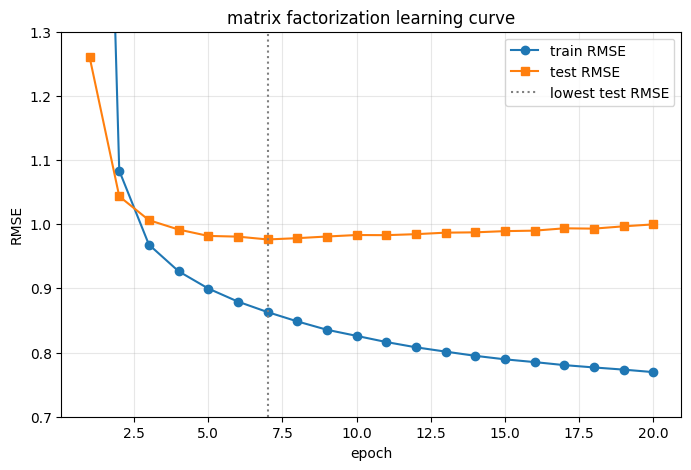

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_curve, marker='o', label='train RMSE')
plt.plot(range(1, n_epochs + 1), test_curve, marker='s', label='test RMSE')
plt.axvline(np.argmin(test_curve) + 1, color='gray', linestyle=':', label='lowest test RMSE')
plt.ylim(0.7, 1.3)
plt.xlabel('epoch')
plt.ylabel('RMSE')
plt.title('matrix factorization learning curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

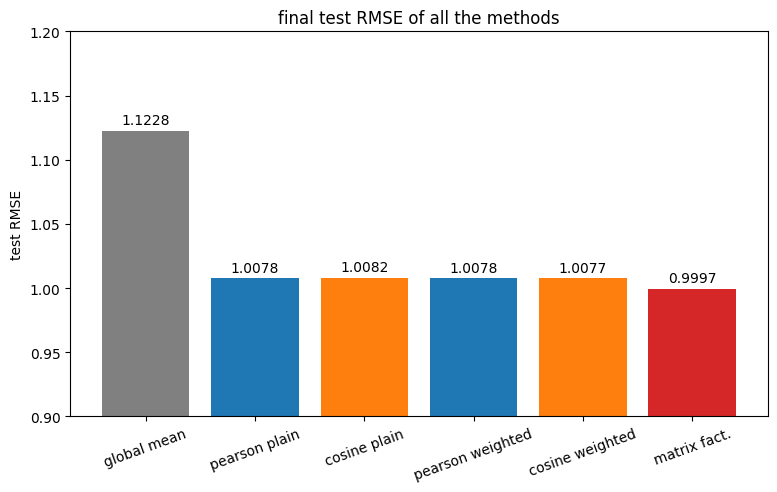

In [36]:
names = ['global mean', 'pearson plain', 'cosine plain', 'pearson weighted', 'cosine weighted', 'matrix fact.']
values = [results['test RMSE'].iloc[6], results['test RMSE'].iloc[0], results['test RMSE'].iloc[1],
          results['test RMSE'].iloc[2], results['test RMSE'].iloc[3], results['test RMSE'].iloc[4]]

plt.figure(figsize=(9, 5))
bars = plt.bar(names, values, color=['gray', 'tab:blue', 'tab:orange', 'tab:blue', 'tab:orange', 'tab:red'])
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f"{v:.4f}", ha='center')
plt.ylim(0.9, 1.2)
plt.ylabel('test RMSE')
plt.title('final test RMSE of all the methods')
plt.xticks(rotation=20)
plt.show()

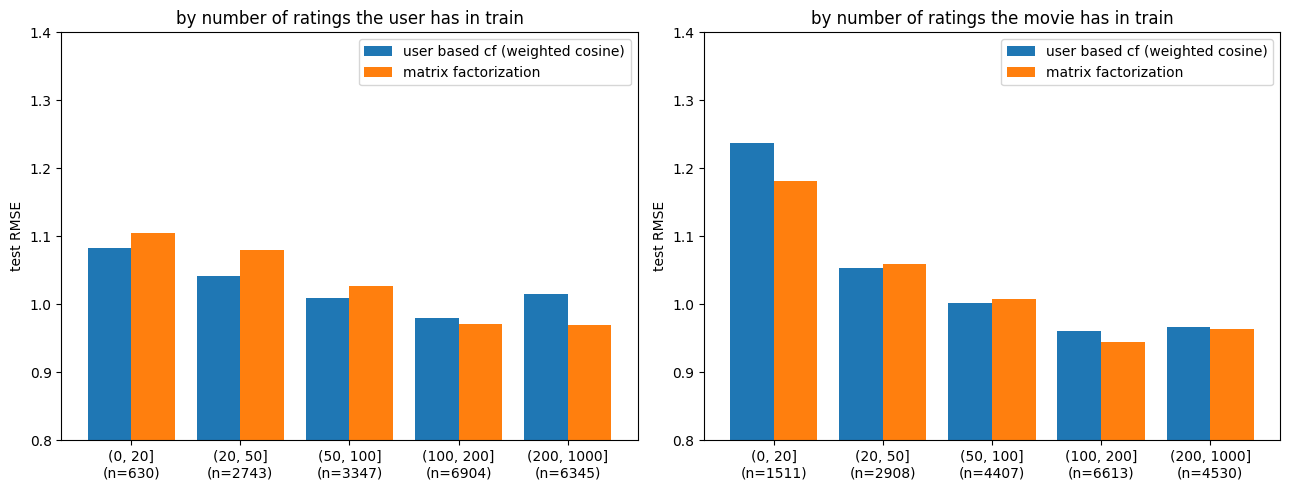

(             knn_sq   mf_sq
 user_group                 
 (0, 20]      1.0822  1.1047
 (20, 50]     1.0411  1.0801
 (50, 100]    1.0094  1.0264
 (100, 200]   0.9791  0.9705
 (200, 1000]  1.0150  0.9693,
              knn_sq   mf_sq
 item_group                 
 (0, 20]      1.2367  1.1818
 (20, 50]     1.0529  1.0588
 (50, 100]    1.0015  1.0081
 (100, 200]   0.9598  0.9445
 (200, 1000]  0.9662  0.9641)

In [37]:
kept = test_data[test_data['user_id'].isin(user_to_idx) & test_data['item_id'].isin(item_to_idx)]
user_counts = train_data['user_id'].value_counts()
item_counts = train_data['item_id'].value_counts()

knn_best = cosine_preds[:, best_c]
bins = [0, 20, 50, 100, 200, 1000]

by_user = pd.cut(kept['user_id'].map(user_counts).to_numpy(), bins)
by_item = pd.cut(kept['item_id'].map(item_counts).to_numpy(), bins)

group_df = pd.DataFrame({
    'user_group': by_user,
    'item_group': by_item,
    'knn_sq': (knn_best - actual) ** 2,
    'mf_sq': (mf_preds - actual) ** 2
})

user_rmse = group_df.groupby('user_group', observed=True)[['knn_sq', 'mf_sq']].mean() ** 0.5
item_rmse = group_df.groupby('item_group', observed=True)[['knn_sq', 'mf_sq']].mean() ** 0.5
user_size = group_df['user_group'].value_counts().sort_index()
item_size = group_df['item_group'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tab, size, title in zip(axes, [user_rmse, item_rmse], [user_size, item_size],
                                ['by number of ratings the user has in train', 'by number of ratings the movie has in train']):
    x = np.arange(len(tab))
    ax.bar(x - 0.2, tab['knn_sq'], 0.4, label='user based cf (weighted cosine)')
    ax.bar(x + 0.2, tab['mf_sq'], 0.4, label='matrix factorization')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{str(g)}\n(n={s})" for g, s in zip(tab.index, size[tab.index])])
    ax.set_ylim(0.8, 1.4)
    ax.set_ylabel('test RMSE')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()
user_rmse.round(4), item_rmse.round(4)

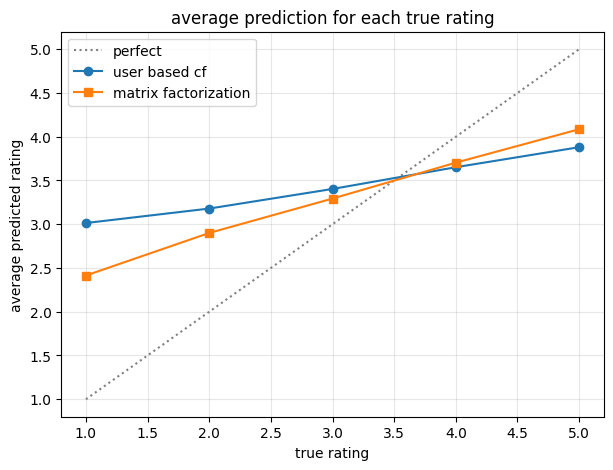

In [38]:
true_ratings = [1, 2, 3, 4, 5]
knn_mean = [knn_best[actual == r].mean() for r in true_ratings]
mf_mean = [mf_preds[actual == r].mean() for r in true_ratings]

plt.figure(figsize=(7, 5))
plt.plot(true_ratings, true_ratings, color='gray', linestyle=':', label='perfect')
plt.plot(true_ratings, knn_mean, marker='o', label='user based cf')
plt.plot(true_ratings, mf_mean, marker='s', label='matrix factorization')
plt.xlabel('true rating')
plt.ylabel('average predicted rating')
plt.title('average prediction for each true rating')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# conclusion

**dataset.** movielens 100k (943 users, 1682 movies, 100000 ratings from 1 to 5, about 94% of the user-movie matrix is empty). it is a good fit because the ratings are real explicit feedback from real users and it is sparse like a real recommender problem, and it is still small enough that both methods can be run in a notebook. the split is one random 80/20 split (`random_state=42`) used for both methods. the 31 test ratings whose user or movie is not in train are left out for both methods, so both are scored on the same 19969 ratings.

**results (test RMSE, lower is better)**

| method | test RMSE |
|---|---|
| predict global mean for everything | 1.1228 |
| user based cf, pearson, plain mean (k=30) | 1.0078 |
| user based cf, cosine, plain mean (k=30) | 1.0082 |
| user based cf, pearson, weighted (k=40) | 1.0078 |
| user based cf, cosine, weighted (k=30) | 1.0077 |
| matrix factorization, 10 factors, 20 epochs | 0.9997 |
| matrix factorization, best epoch 7 (optimistic, picked on test) | 0.9763 |

**what we can see**

1. both methods are clearly better than the global mean baseline (about 10% lower error), so they really learn something from the behaviour of the users.
2. weighting the neighbours by similarity (the formula from the worked example) did not change much, the difference is at most 0.002. the top neighbours of a user have quite similar similarity values, so the weighted average comes out almost the same as the plain mean. also pearson is calculated on the matrix where the empty cells are filled with 0, so it behaves almost like cosine, that is why both give nearly the same numbers.
3. for kNN the error falls quickly until k = 20 and then stays flat, so after about 30 neighbours more neighbours do not help.
4. matrix factorization is better than the best kNN by 0.008 RMSE (about 0.8%) at 20 epochs. this is a small gap and it is from one split and one seed, so we should not oversell it. the learning curve shows the model overfits: the train rmse keeps falling to 0.77 but the test rmse is lowest at epoch 7 and then goes up. so the regularization (lambda = 0.01) is too weak or training should stop earlier. adding user and item biases and a proper validation set would very likely improve it further.
5. speed is where the two are really different. one kNN prediction takes about 0.63 ms because it has to look for the neighbours of the user and everyone who rated the movie, while one matrix factorization prediction is a single dot product and takes about 0.002 ms (more than 300 times faster). matrix factorization pays this once with about 12 seconds of training. kNN also needs the full user x user similarity matrix, which grows with the square of the number of users.
6. the group plots show where each method is better. for users with less than 100 ratings in train, kNN is slightly better (for example 1.08 vs 1.10 for users with less than 20 ratings). for users with more than 100 ratings matrix factorization is better and the gap is biggest for the heaviest users (0.969 vs 1.015). for movies with less than 20 ratings in train matrix factorization is better (1.18 vs 1.24). so with this setup the usual claim "matrix factorization handles sparse users better" is not what we see, a user with few ratings does not give enough data to learn a good latent vector from, while kNN can still borrow from similar users. these gaps are small and from one run so treat them as hints.
7. the last plot shows both models pull the predictions towards the middle (a true 1 star is predicted as about 2.4 by matrix factorization and 3.0 by kNN), kNN does this more because it averages ratings of many neighbours.

**when to use which**

- memory based (user based cf) is preferable when the data is small, when we want no training step, when we need to explain the recommendation ("users similar to you liked this"), or when new ratings must be used immediately because nothing has to be retrained. it is also a bit more robust for users with very few ratings. its weak points are slow predictions and the similarity matrix that grows quadratically with the users.
- model based (matrix factorization) is preferable when there are many users and items, when predictions must be fast (the model is just two small matrices), and when we have many ratings per user to learn from. it also can be extended easily (biases, regularization, implicit feedback). the price is a training step, hyperparameters to tune (factors, learning rate, lambda, epochs) and the risk of overfitting that we saw in the learning curve.

**limits of this notebook.** one random split, no separate validation set, hyperparameters were not tuned, matrix factorization has no bias terms, and pearson uses the zero filled matrix. a next step would be k-fold cross validation, tuning lambda and the number of factors on a validation set, and adding the global mean plus user and item biases.